# During this notebook, we are comparing all models including machine learning and deep learning 

In order to compare these model, we need to wrap deep learning models in some to class in order to obtain a similar behavior to ml models from sklearn i.e. to have predict and fit methods 

In [1]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import MinMaxScaler
import numpy as np

First create our deep learning models

In [2]:
class RecurrentNN(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size, input_size):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.input_size = input_size

    def _build_model(self):
        class RNN(nn.Module):
            def __init__(self, input_size, hidden_size):
                super().__init__()
                self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
                self.fc = nn.Linear(hidden_size, 1)
            def forward(self, x):
                out, _ = self.rnn(x)  ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
                return self.fc(out[:, -1, :]).squeeze(-1)
        return RNN(self.input_size, self.hidden_size)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [3]:
class MLP_two_layers(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size_1, hidden_size_2, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size_1, hidden_size_2):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size_1)
                self.linear_2 = nn.Linear(in_features=hidden_size_1, out_features=hidden_size_2)
                self.linear_3 = nn.Linear(in_features=hidden_size_2, out_features=1)
               
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = torch.relu(self.linear_2(x))
                x = self.linear_3(x)
                return x.squeeze(-1)
            
        return Fully_Connected(self.in_features, self.hidden_size_1, self.hidden_size_2)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [4]:
class MLP_three_layers(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size_1, hidden_size_2, hidden_size_3, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.hidden_size_3 = hidden_size_3
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size_1, hidden_size_2, hidden_size_3):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size_1)
                self.linear_2 = nn.Linear(in_features=hidden_size_1, out_features=hidden_size_2)
                self.linear_3 = nn.Linear(in_features=hidden_size_2, out_features=hidden_size_3)
                self.output_layer = nn.Linear(in_features=hidden_size_3, out_features=1)
               
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = torch.relu(self.linear_2(x))
                x = torch.relu(self.linear_3(x))
                x = self.output_layer(x)
                return x.squeeze(-1)
            
        return Fully_Connected(self.in_features, self.hidden_size_1, self.hidden_size_2, self.hidden_size_3)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [5]:
class MLP_one_layer(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size)
                self.linear_2 = nn.Linear(in_features=hidden_size, out_features=1)
          
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = self.linear_2(x)
                return x.squeeze(-1)
            
        return Fully_Connected(in_features=self.in_features, hidden_size=self.hidden_size)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

Let's compare the models 

In [6]:
import sys
import os

project_root = os.path.abspath("..") 
sys.path.append(project_root)

from scripts.compare_models import Models_Horizon

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 

Define our parameters 

In [8]:
cut_point = 2290
test_size = 288 ## To work with TimeSeriesSplit
window_size = 12
folds = 5
batch_size = 256 ## Just for nn 
lr = 0.01 
epochs = 300
metrics = [
    mean_squared_error, 
    mean_absolute_error, 
    mean_absolute_percentage_error, 
    root_mean_squared_error
]
metric_names = ['MSE', 'MAE', 'MAPE', 'RMSE']
models = [
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), 
                     ('linear_regression', LinearRegression())]),
    RecurrentNN(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size=window_size*2, input_size=1),
    MLP_one_layer(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size=window_size*2, in_features=window_size),
    MLP_two_layers(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size_1=window_size*2, hidden_size_2=window_size*2, in_features=window_size),
    MLP_three_layers(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size_1=window_size*2, hidden_size_2=window_size*2, hidden_size_3=window_size*2, in_features=window_size)
]
model_names = [
    'LinearRegression',
    'RecurrentNN_one_layer',
    'MLP_one_layer', 
    'MLP_two_layers',
    'MLP_three_layers'
]

Results for horizon 3:
metric                 MSE                                                     \
model     LinearRegression RecurrentNN_one_layer MLP_one_layer MLP_two_layers   
HUPA0004P        50.221597             59.133762    108.488250     135.890634   
HUPA0006P        49.198094             60.666523     80.511768     101.716992   
HUPA0007P       415.206268            396.626592    414.092605     374.856563   
HUPA0009P        15.361869             17.104987     26.507123      29.394975   
HUPA0005P        97.554003            103.754913    119.376831     142.010959   
HUPA0011P       134.409388            149.174516    176.007337     164.743841   
HUPA0003P       134.358384            135.164977    151.252366     158.519937   
HUPA0001P       273.949145            276.673834    291.614430     293.150323   
HUPA0010P        58.754991             66.841141    101.810523      93.554304   
HUPA0002P        39.442100             52.359108     69.656548      70.857299   
HUPA0

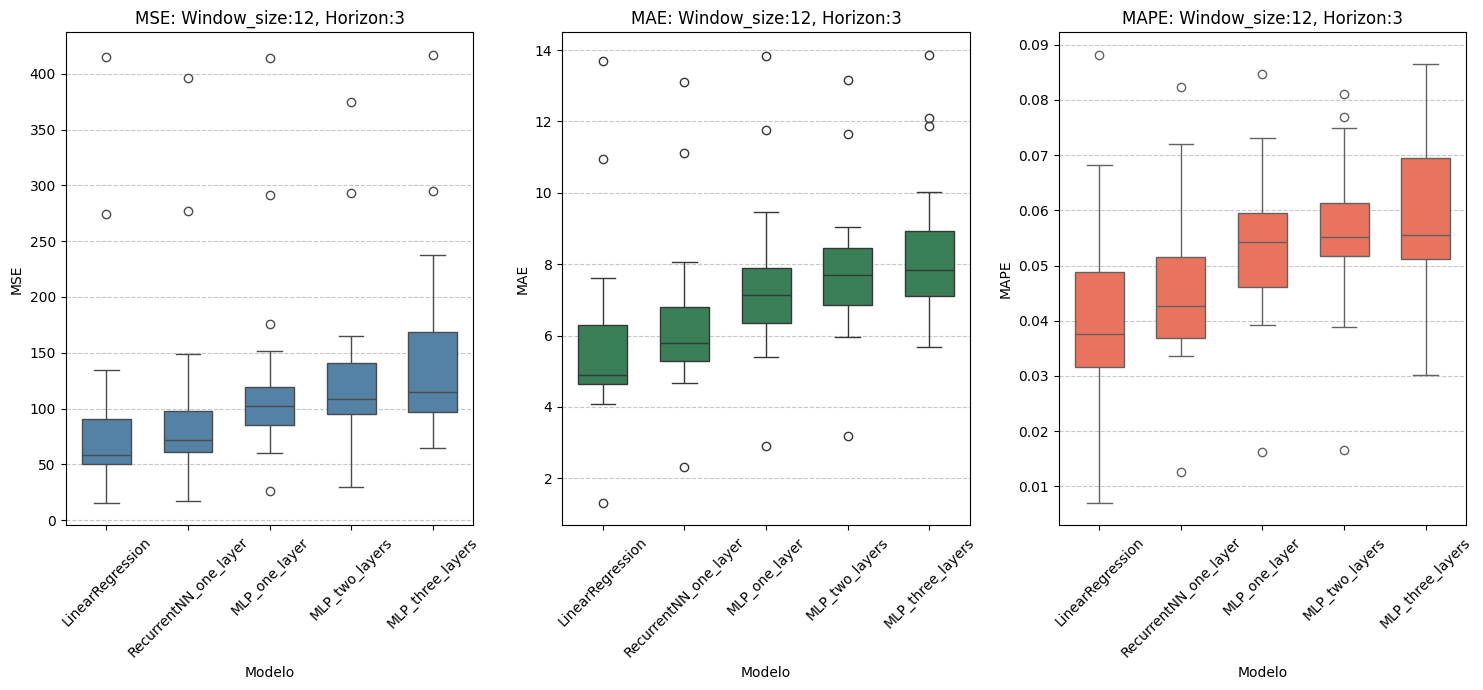

MSE
model  LinearRegression  RecurrentNN_one_layer  MLP_one_layer  MLP_two_layers  \
count         25.000000              25.000000      25.000000       25.000000   
mean          88.871061              97.473005     120.423874      127.079702   
std           84.746722              79.673119      77.771361       69.741481   
min           15.361869              17.104987      26.507123       29.394975   
25%           50.221597              60.666523      85.477369       95.531540   
50%           58.126308              71.466337     101.810523      108.658258   
75%           90.329290              97.935724     119.376831      141.118654   
max          415.206268             396.626592     414.092605      374.856563   

model  MLP_three_layers  
count         25.000000  
mean         141.952084  
std           78.372715  
min           64.218267  
25%           97.276204  
50%          114.923388  
75%          168.832717  
max          417.027037  
MAE
model  LinearRegression  Rec

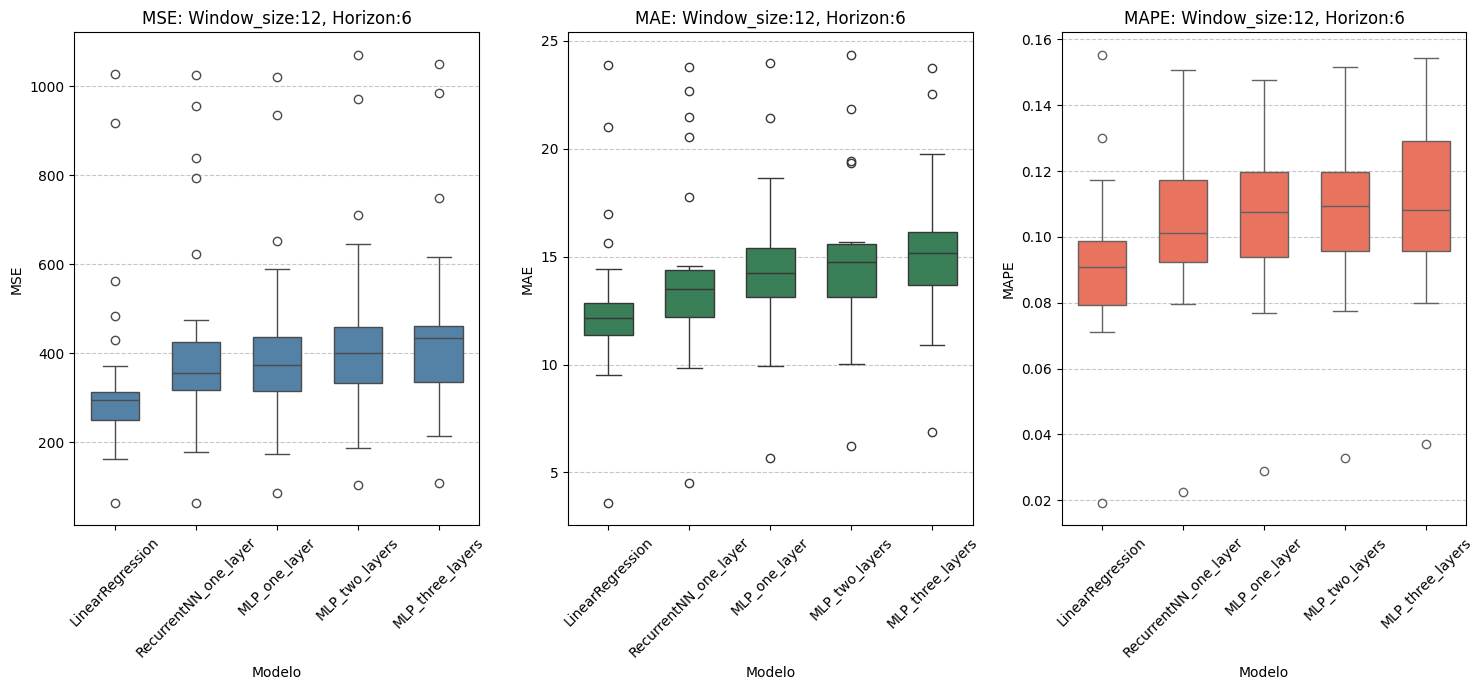

MSE
model  LinearRegression  RecurrentNN_one_layer  MLP_one_layer  MLP_two_layers  \
count         25.000000              25.000000      25.000000       25.000000   
mean         345.177746             419.951013     411.481684      440.868346   
std          213.660547             240.970129     206.795607      219.138252   
min           64.258559              63.422641      84.819632      104.612533   
25%          249.539545             318.357889     314.042422      333.651644   
50%          294.797537             355.640520     372.346460      400.786672   
75%          311.650913             425.571152     436.345627      459.533373   
max         1027.007682            1025.723186    1021.163279     1070.566385   

model  MLP_three_layers  
count         25.000000  
mean         454.969638  
std          213.631129  
min          107.493830  
25%          336.024772  
50%          434.092229  
75%          460.561713  
max         1049.321147  
MAE
model  LinearRegression  Rec

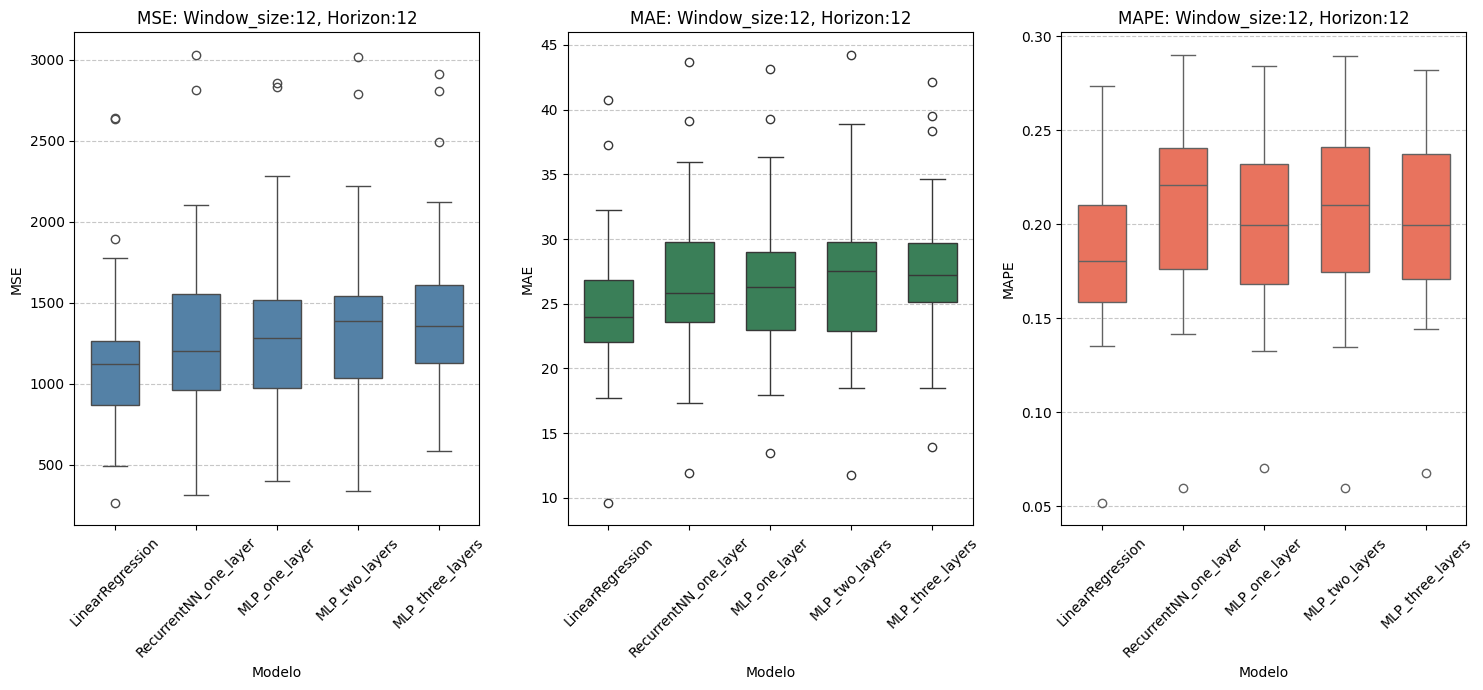

MSE
model  LinearRegression  RecurrentNN_one_layer  MLP_one_layer  MLP_two_layers  \
count         25.000000              25.000000      25.000000       25.000000   
mean        1164.041678            1331.662335    1323.684667     1388.349123   
std          574.271370             647.603002     631.317814      629.968332   
min          265.530049             316.857658     398.901822      338.182952   
25%          868.219523             959.807939     975.922634     1036.332908   
50%         1123.346837            1203.111148    1285.193497     1390.498895   
75%         1266.431041            1555.774740    1517.746794     1542.358047   
max         2643.823940            3031.579819    2859.938148     3015.283585   

model  MLP_three_layers  
count         25.000000  
mean        1437.507170  
std          621.248470  
min          585.533271  
25%         1132.290016  
50%         1356.709661  
75%         1613.383933  
max         2911.881369  
MAE
model  LinearRegression  Rec

In [9]:
for h_i in [3,6,12]:
    evaluator_h_i = Models_Horizon(cut_point=cut_point, test_size=test_size, window_size=window_size, horizon=h_i,
                        folds=folds, models=models, model_names=model_names, metrics=metrics, metric_names=metric_names)
    result_i = evaluator_h_i.test_models()
    print(f'Results for horizon {h_i}:')
    print(result_i)
    evaluator_h_i.visualize_model_comparison()